# Task 3 — Visualisations

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"C:\Users\Rohit\Downloads\cleaned_shopease_orders_2023_2024.csv")
df


,order_id,order_date,year,month,customer_id,customer_age,customer_city,region,category,product_name,quantity,unit_price_inr,discount_pct,net_revenue_inr,payment_method,order_status,delivery_days,return_reason,age_group
0,ORD-2081,2023-01-03,2023,January,CUST-701,37,Nagpur,West,Toys & Games,Lego Set (200 pcs),3,7479.56,10,20194.81,COD,Delivered,12.0,NaN,36-45
1,ORD-2012,2023-01-04,2023,January,CUST-612,34,Pune,West,Toys & Games,Remote Control Car,3,3533.65,25,7950.71,UPI,Cancelled,NaN,NaN,26-35
2,ORD-2650,2023-01-04,2023,January,CUST-412,58,Lucknow,North,Home & Kitchen,Coffee Maker,6,3601.90,0,21611.40,Debit Card,Delivered,4.0,NaN,46+
3,ORD-2188,2023-01-07,2023,January,CUST-557,33,Lucknow,North,Electronics,Power Bank,2,3870.89,5,7354.69,Debit Card,Delivered,7.0,NaN,26-35
4,ORD-2228,2023-01-07,2023,January,CUST-489,57,Guwahati,East,Clothing,Winter Jacket,4,944.08,10,3398.69,Debit Card,Delivered,6.0,NaN,46+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD-2752,2024-12-29,2024,December,CUST-233,27,Ahmedabad,West,Books,Atomic Habits,5,7818.10,20,31272.40,UPI,Delivered,2.0,NaN,26-35
996,ORD-2868,2024-12-29,2024,December,CUST-148,38,Pune,West,Home & Kitchen,Coffee Maker,3,2971.25,15,7576.69,UPI,Delivered,4.0,NaN,36-45
997,ORD-2961,2024-12-29,2024,December,CUST-348,53,Guwahati,East,Toys & Games,Soft Plush Toy,1,2183.12,10,1964.81,Wallet,Delivered,6.0,NaN,46+
998,ORD-2323,2024-12-30,2024,December,CUST-381,59,Bhopal,Central,Beauty,Face Wash,2,2092.88,10,3767.18,Net Banking,Cancelled,NaN,NaN,46+


# 1. Bar chart Total net revenue by category (both years combined)

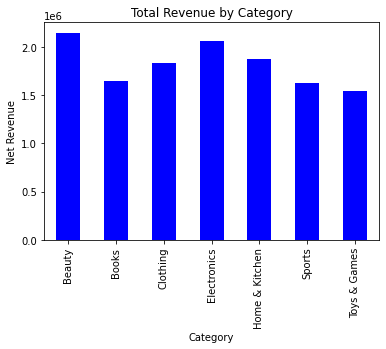

In [44]:
category_rev = df.groupby('category')['net_revenue_inr'].sum()
category_rev.plot(kind='bar', color='blue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Net Revenue')
plt.show()

# 2. Line chart Monthly net revenue trend — show 2023 and 2024 as two separate lines

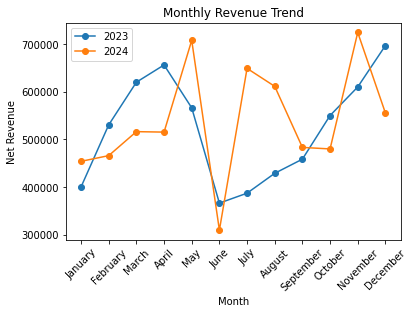

In [45]:
monthly = df.groupby(['year','month'])['net_revenue_inr'].sum().unstack('year')

# Reorder months
months_order = ["January","February","March","April","May","June",
                "July","August","September","October","November","December"]
monthly = monthly.reindex(months_order)

# Plot 2023 and 2024 as two lines
plt.plot(monthly.index, monthly[2023], marker='o', label='2023')
plt.plot(monthly.index, monthly[2024], marker='o', label='2024')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 3. Grouped bar Order count by status (Delivered / Returned / Cancelled) per region

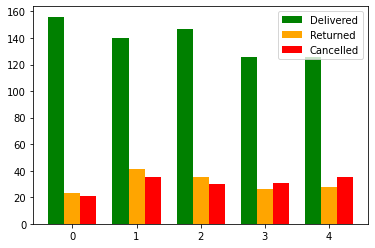

In [46]:
status_region = df.groupby(['region','order_status']).size().unstack(fill_value=0)
regions = status_region.index
x = np.arange(len(regions))
plt.bar(x - width, status_region['Delivered'], width, label='Delivered', color='green')
plt.bar(x, status_region['Returned'], width, label='Returned', color='orange')
plt.bar(x + width, status_region['Cancelled'], width, label='Cancelled', color='red')
plt.legend()

# 4. Donut Payment method share across all orders

In [47]:
payment_counts = df['payment_method'].value_counts()
payment_counts

payment_method
Wallet         187
UPI            175
Net Banking    171
Debit Card     168
COD            159
Credit Card    140
Name: count, dtype: int64

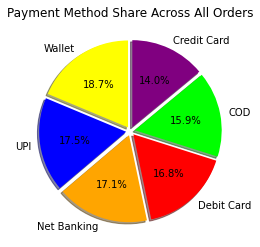

In [48]:

colors = ['yellow', 'blue', 'orange', 'red', 'lime', 'purple']
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=colors,explode=explode, shadow=True)
plt.title("Payment Method Share Across All Orders")
plt.show()

# 5. Your choice Any insight you find interesting — explain your chart choice in 1–2 sentences

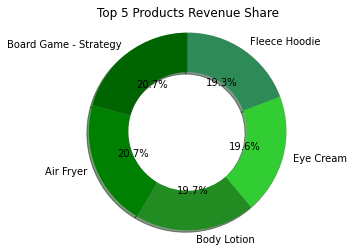

In [52]:
colors = ['darkgreen', 'green', 'forestgreen', 'limegreen', 'seagreen']

plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=90,shadow=True,
        colors=colors, wedgeprops={'width':0.4})
plt.title("Top 5 Products Revenue Share")
plt.axis('equal')
plt.show()

i used donut chart shows how much each of the top 5 products contributes to total revenue, It helps see which products make the most money compared to others.